<a href="https://colab.research.google.com/github/Andysun01/Makcik-gejrot/blob/main/UTS_Lab_Machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UTS Lab. Machine learning individu

Andy - NPM 2431075

DATASET LINK

https://www.kaggle.com/datasets/ziya07/hospital-energy-saving-system-dataset

In [130]:
#Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Dataset download link
!gdown "https://drive.google.com/file/d/1qY_o8MJZNEDeaBJEWGWxcwmBVRrq7Oun/view?usp=sharing" -O Mall_Customers.csv --fuzzy
data = pd.read_csv("Mall_Customers.csv")

!gdown "https://drive.google.com/file/d/1l6Mg6sClv0SkPTkbHnnhQ0XBFpLLkLnV/view?usp=sharing" -O hospital_communication_energy_system.csv --fuzzy
df = pd.read_csv("hospital_communication_energy_system.csv")


Downloading...
From: https://drive.google.com/uc?id=1qY_o8MJZNEDeaBJEWGWxcwmBVRrq7Oun
To: /content/Mall_Customers.csv
100% 3.98k/3.98k [00:00<00:00, 8.37MB/s]
Downloading...
From: https://drive.google.com/uc?id=1l6Mg6sClv0SkPTkbHnnhQ0XBFpLLkLnV
To: /content/hospital_communication_energy_system.csv
100% 2.39M/2.39M [00:00<00:00, 35.5MB/s]



##Classification

In [109]:
#Data cleaning
df.info()
df.duplicated().sum()

#Feature selection
excluded_cols = ['Timestamp', 'Energy Consumption (kWh)', 'Energy Source',
                'Renewable Energy Usage (%)', 'Lighting Power Usage (kWh)',
                'Total Power Usage (kWh)', 'Day of the Week', 'Season',
                'Energy Saving Mode', 'Patient ID', 'Outdoor Humidity (%)',
                'System Health Check', 'Humidity (%)', 'HVAC Efficiency (%)',
                'HVAC Power Usage (kWh)', 'Outdoor Temperature (°C)']

df.drop(columns=excluded_cols, inplace=True)

#Feature construction
df['Blood Pressure (mmHg)'] = df['Blood Pressure (mmHg)'].str.replace(r'[(),]', '', regex=True)
df[['Systolic Blood Pressure (mmHg)', 'Diastolic Blood Pressure (mmHg)']] = df['Blood Pressure (mmHg)'].str.split(' ', expand=True)
df['Systolic Blood Pressure (mmHg)'] = pd.to_numeric(df['Systolic Blood Pressure (mmHg)'])
df['Diastolic Blood Pressure (mmHg)'] = pd.to_numeric(df['Diastolic Blood Pressure (mmHg)'])
df.drop(columns=['Blood Pressure (mmHg)'], inplace=True)

#Check outliers
cols_to_check = [col for col in df.columns if col not in excluded_cols]
numeric_cols = df[cols_to_check].select_dtypes(include=['number']).columns

print("___ HASIL DETEKSI OUTLIER (METODE IQR) ___")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outlier ditemukan (Batas: {lower_bound:.2f} s/d {upper_bound:.2f})")

    df = df[(df['Room Humidity (%)'] >= 40) & (df['Room Humidity (%)'] <= 60)]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Timestamp                            10000 non-null  object 
 1   Patient ID                           10000 non-null  object 
 2   Temperature (°C)                     10000 non-null  float64
 3   Humidity (%)                         10000 non-null  float64
 4   Oxygen Level (%)                     10000 non-null  float64
 5   Heart Rate (bpm)                     10000 non-null  int64  
 6   Blood Pressure (mmHg)                10000 non-null  object 
 7   Energy Consumption (kWh)             10000 non-null  float64
 8   Energy Source                        10000 non-null  object 
 9   Renewable Energy Usage (%)           10000 non-null  float64
 10  HVAC Power Usage (kWh)               10000 non-null  float64
 11  Lighting Power Usage (kWh)   

## Preprocessing untuk Pelatihan Model

Preprocessing adalah tahap awal dalam pengolahan data yang bertujuan untuk membersihkan, memperbaiki, dan menyiapkan data mentah agar menjadi lebih rapi, konsisten, dan siap digunakan dalam analisis atau pelatihan model machine learning.. Langkah-langkah yang digunakan:
1.  **Data cleaning**: proses membersihkan data dari kesalahan, nilai yang tidak valid, duplikasi, dan ketidakkonsistenan agar data menjadi akurat, rapi, dan layak digunakan untuk analisis atau machine learning.
2.  **Feature selection**: proses memilih fitur (variabel/kolom) yang paling relevan dari dataset untuk digunakan dalam model machine learning, sambil menghapus fitur yang tidak penting atau redundant.
3.  **Feature construction**: Feature construction adalah proses membuat fitur (variabel) baru dari data yang sudah ada untuk membantu model machine learning menangkap pola dengan lebih baik.
4.  **Interquartile range**: untuk mengukur sebaran data normal dan mendeteksi nilai yang tidak wajar (outlier).

/tmp/ipykernel_11275/3695953030.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Cooling', 'Heating'])


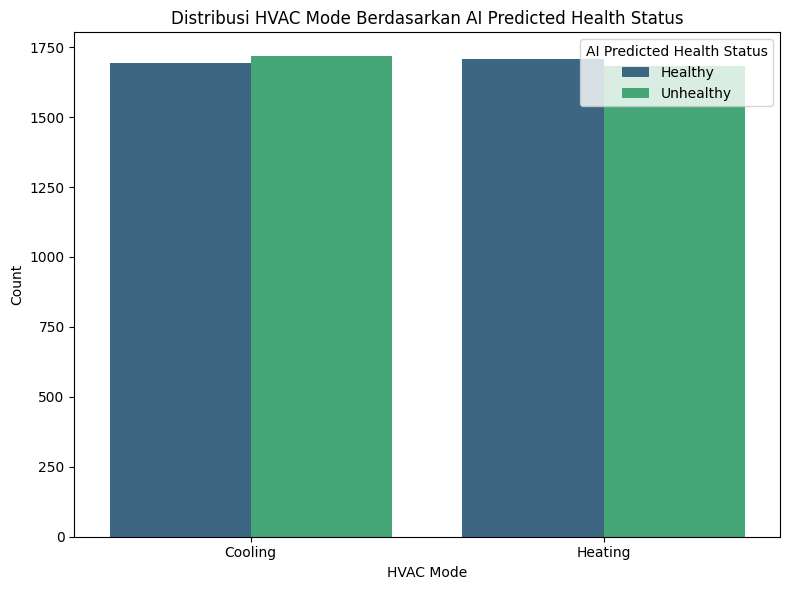

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
ax = sns.countplot(
    x='HVAC Mode',
    hue='AI Predicted Health Status',
    data=df,
    palette='viridis'
)
plt.title('Distribusi HVAC Mode Berdasarkan AI Predicted Health Status')
plt.xlabel('HVAC Mode')
plt.ylabel('Count')
ax.set_xticklabels(['Cooling', 'Heating'])
plt.legend(title='AI Predicted Health Status', labels=['Healthy', 'Unhealthy'])
plt.tight_layout()
plt.show()

Disini saya mengunakan grafik count plot yang saya buat untuk melihat hubungan antara HVAC Mode dan Status Kesehatan yang Diprediksi AI.

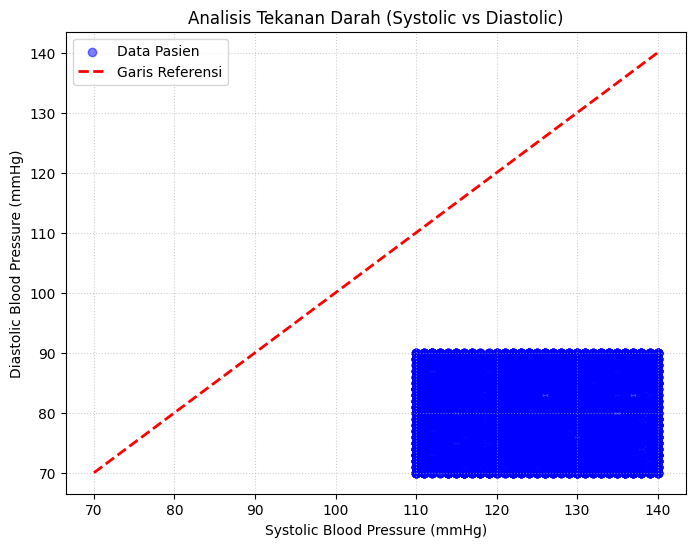

In [111]:
x = df['Systolic Blood Pressure (mmHg)']
y = df['Diastolic Blood Pressure (mmHg)']

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.5, color='blue', label='Data Pasien')
line_coords = [min(x.min(), y.min()), max(x.max(), y.max())]
plt.plot(line_coords, line_coords, 'r--', lw=2, label='Garis Referensi')
plt.title('Analisis Tekanan Darah (Systolic vs Diastolic)')
plt.xlabel('Systolic Blood Pressure (mmHg)')
plt.ylabel('Diastolic Blood Pressure (mmHg)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Disini saya juga menggunakan grafik scatter plot untuk melihat hubungan antara Tekanan Darah Sistolik dan Tekanan Darah Diastolik pada pasien.

Berdasarkan hasil visualisasi, dapat disimpulkan bahwa hubungan antara tekanan darah sistolik dan diastolik terhadap kondisi kesehatan pasien menunjukkan korelasi yang sangat lemah, bahkan cenderung tidak signifikan. Hal ini mengindikasikan bahwa kedua variabel tersebut tidak memiliki pengaruh yang kuat dalam menentukan status kesehatan pasien pada dataset ini.

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6804 entries, 1 to 9998
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Temperature (°C)                     6804 non-null   float64
 1   Oxygen Level (%)                     6804 non-null   float64
 2   Heart Rate (bpm)                     6804 non-null   int64  
 3   Medical Equipment Power Usage (kWh)  6804 non-null   float64
 4   Room Temperature (°C)                6804 non-null   float64
 5   Room Humidity (%)                    6804 non-null   float64
 6   HVAC Mode                            6804 non-null   object 
 7   AI Predicted Health Status           6804 non-null   object 
 8   Systolic Blood Pressure (mmHg)       6804 non-null   int64  
 9   Diastolic Blood Pressure (mmHg)      6804 non-null   int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 584.7+ KB


In [113]:
# Split data
label_encoder = LabelEncoder()
df['AI Predicted Health Status'] = label_encoder.fit_transform(df['AI Predicted Health Status'])
df['HVAC Mode'] = label_encoder.fit_transform(df['HVAC Mode'])

x=df.drop(columns=['AI Predicted Health Status'])
y=df['AI Predicted Health Status']

model=RandomForestClassifier(n_estimators=100,random_state=42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model.fit(x_train,y_train)

# Training data
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

y_pred=model.predict(x_test)

# Accuracy
report = classification_report(y_test, y_pred)
print('Classification Report:\n', report)

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.54      0.53       673
           1       0.52      0.49      0.51       688

    accuracy                           0.52      1361
   macro avg       0.52      0.52      0.52      1361
weighted avg       0.52      0.52      0.52      1361



Confusion matrix adalah tabel yang digunakan untuk membandingkan hasil prediksi model dengan data sebenarnya.disini confusion matrix dijelaskan karena menjadi dasar dalam perhitungan seluruh metrik evaluasi, yang berasal dari nilai TP, TN, FP, dan FN. Dengan memahami confusion matrix, interpretasi terhadap metrik seperti accuracy, precision, recall, dan f1-score dapat dilakukan secara lebih jelas dan terstruktur.

Berikut adalah beberapa metrik yang digunakan dalam evaluasi model:

1. Accuracy

Accuracy mengukur proporsi prediksi yang benar dari seluruh data.

Rumus:

TP+TN/TP+TN+FP+FN



Penjelasan:
Nilai accuracy sebesar 0.52 (52%) menunjukkan bahwa model hanya mampu memprediksi dengan benar sekitar 52% dari total data. Nilai ini tergolong rendah, sehingga model belum memiliki performa yang baik.

2. Precision

Precision mengukur seberapa akurat prediksi positif yang dihasilkan oleh model.

Rumus:

TP/TP+FP


Penjelasan:
Precision menunjukkan tingkat ketepatan model ketika memberikan prediksi positif. Nilai precision yang rendah mengindikasikan bahwa model masih sering menghasilkan prediksi yang salah.

3. Recall

Recall mengukur kemampuan model dalam mendeteksi seluruh data yang benar-benar positif.

Rumus:

TP/TP+FN


Penjelasan:
Recall yang rendah menunjukkan bahwa model belum mampu menangkap seluruh data yang seharusnya terklasifikasi dengan benar.

4. F1-Score

F1-score merupakan rata-rata harmonik dari precision dan recall.

Rumus:

2×Precision+Recall/Precision×Recall
	​

Penjelasan:
Nilai F1-score sekitar 0.52 menunjukkan bahwa keseimbangan antara precision dan recall masih belum optimal, sehingga performa model secara keseluruhan masih lemah.

/tmp/ipykernel_11275/1254588072.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importance.values, y=sorted_importance.index, palette='viridis')


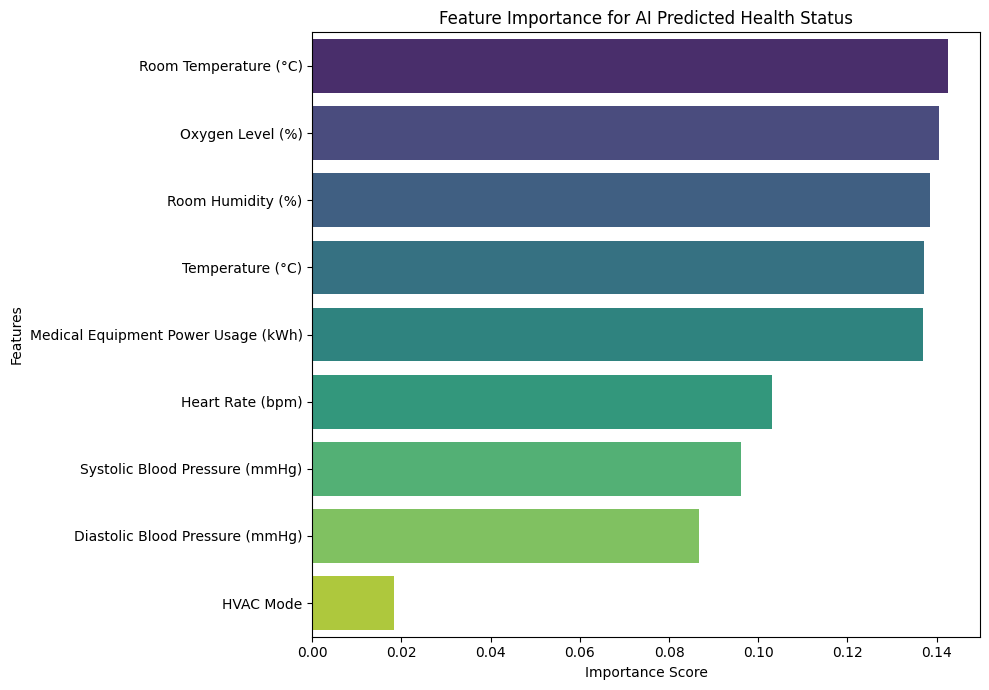

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = model.feature_importances_
feature_names = x_train.columns
importance_series = pd.Series(feature_importances, index=feature_names)
sorted_importance = importance_series.sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=sorted_importance.values, y=sorted_importance.index, palette='viridis')
plt.title('Feature Importance for AI Predicted Health Status')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Visualisasi *feature importance* ini menunjukkan seberapa besar kontribusi setiap fitur dalam memprediksi 'AI Predicted Health Status' oleh model Random Forest yang telah dilatih.

##Clustering

In [159]:
data = data.rename (columns={'Annual Income (k$)' : 'Annual Income',
                    'Spending Score (1-100)' : 'Spending Score'})

features = ['Age', 'Annual Income', 'Spending Score']
X = data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_scaled, X_test_scaled, _, _ = train_test_split(
    X_scaled, X_scaled, test_size=0.2, random_state=42
)

print(f"Ukuran data pelatihan: {X_train_scaled.shape[0]} sampel")
print(f"Ukuran data pengujian: {X_test_scaled.shape[0]} sampel")

kmeans_model = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_model.fit(X_train_scaled)

train_clusters = kmeans_model.predict(X_train_scaled)
test_clusters = kmeans_model.predict(X_test_scaled)


Ukuran data pelatihan: 160 sampel
Ukuran data pengujian: 40 sampel

Cluster yang ditetapkan untuk beberapa sampel data pelatihan pertama:
[4 2 1 1 0 2 5 5 2 4]

Cluster yang ditetapkan untuk beberapa sampel data pengujian pertama:
[0 5 1 3 3 0 0 3 3 5]


In [151]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(X_scaled)
data.groupby('Cluster').mean()

K=2, Silhouette Score=0.335
K=3, Silhouette Score=0.358
K=4, Silhouette Score=0.404
K=5, Silhouette Score=0.408
K=6, Silhouette Score=0.431
K=7, Silhouette Score=0.410
K=8, Silhouette Score=0.367
K=9, Silhouette Score=0.374
K=10, Silhouette Score=0.362


,Age,Annual Income,Spending Score
Cluster,,,
0,56.333333,54.266667,49.066667
1,26.794872,57.102564,48.128205
2,41.939394,88.939394,16.969697
3,32.692308,86.538462,82.128205
4,25.000000,25.260870,77.608696
5,45.523810,26.285714,19.380952


In [156]:
cluster_labels = {
    0: "Moderate Spenders",
    1: "Young Professionals",
    2: "High Income, Frugal",
    3: "High-Spending Elite",
    4: "Budget Spenders",
    5: "Low Income, Low Spending"
}

data['Cluster_Label'] = data['Cluster'].map(cluster_labels)

print(data[['Annual Income', 'Spending Score', 'Cluster', 'Cluster_Label']].head())

   Annual Income  Spending Score  Cluster             Cluster_Label
0             15              39        4           Budget Spenders
1             15              81        4           Budget Spenders
2             16               6        5  Low Income, Low Spending
3             16              77        4           Budget Spenders
4             17              40        5  Low Income, Low Spending


<Axes: xlabel='Annual Income', ylabel='Spending Score'>

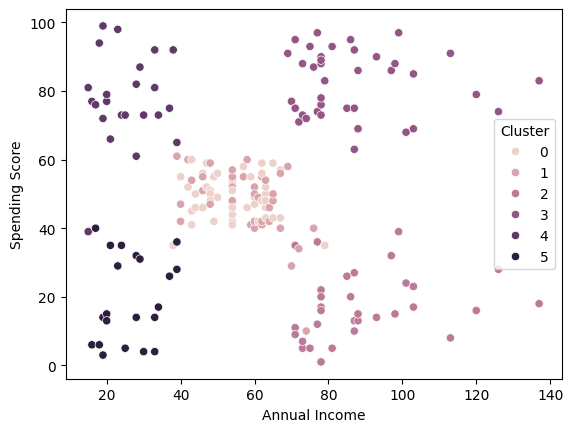

In [157]:
sns.scatterplot(
    x='Annual Income',
    y='Spending Score',
    hue='Cluster',
    data=data
)

**Cluster 0: Pembelanja Moderat.** Kelompok ini terdiri dari pelanggan yang lebih tua, dengan usia rata-rata sekitar 56 tahun. Mereka memiliki pendapatan tahunan sekitar 54.27 ribu dolar dan skor pengeluaran yang moderat, yaitu sekitar 49.07.

**Cluster 1: Profesional Muda.** Kelompok ini ditandai oleh individu yang lebih muda, dengan usia rata-rata sekitar 26 tahun. Mereka kemungkinan besar adalah profesional dengan pendapatan rata-rata sekitar 57.10 ribu dolar dan skor pengeluaran yang juga moderat, sekitar 48.13.

**Cluster 2: Berpenghasilan Tinggi, Hemat.** Pelanggan di segmen ini memiliki pendapatan tahunan yang tinggi, rata-rata sekitar 88.94 ribu dolar, namun skor pengeluaran mereka sangat rendah, yaitu sekitar 16.97. Ini menunjukkan bahwa mereka adalah pembelanja yang sangat hemat.

**Cluster 3: Elit dengan Pengeluaran Tinggi.** Kelompok ini merupakan pelanggan yang paling berharga, dengan usia rata-rata sekitar 32 tahun. Mereka memiliki pendapatan yang tinggi, sekitar 86.54 ribu dolar, dan juga skor pengeluaran yang tinggi, rata-rata sekitar 82.13.

**Cluster 4: Pembelanja Hemat Anggaran.** Kelompok ini terdiri dari pelanggan muda dengan usia rata-rata 25 tahun. Meskipun pendapatan mereka lebih rendah, sekitar 25.26 ribu dolar, mereka memiliki skor pengeluaran yang tinggi, yaitu sekitar 77.61, yang mungkin menunjukkan pembelian yang lebih terfokus pada nilai atau impulsif.

**Cluster 5: Berpenghasilan Rendah, Pengeluaran Rendah.** Kelompok terakhir ini adalah pelanggan paruh baya dengan usia rata-rata sekitar 45 tahun. Mereka memiliki pendapatan rendah, sekitar 26.29 ribu dolar, dan juga skor pengeluaran yang rendah, sekitar 19.38, yang menunjukkan bahwa mereka adalah pembelanja yang sangat sadar anggaran.